# One-way ANOVA: Condition A vs Condition C (pixel AOI, CTA)
Eye-tracking metrics per image. Each metric is compared between the two conditions.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

## 1. Load and clean the data
Converts `12.3%`, `0.59s` to numbers and `N/A` to NaN (images with no fixations).

In [2]:
BASE = Path("../..")
FILE_A = BASE / "Condition A" / "box" / "CTA.csv"
FILE_C = BASE / "Condition B" / "box" / "CTA.csv"


def load(path):
    df = pd.read_csv(path, na_values=["N/A"])
    for col in df.columns.drop("Img"):
        if not pd.api.types.is_numeric_dtype(df[col]):
            df[col] = pd.to_numeric(df[col].astype(str).str.rstrip("%s"), errors="coerce")
    return df


a = load(FILE_A)
c = load(FILE_C)
metrics = [m for m in a.columns if m != "Img"]

print(f"Condition A: {len(a)} images | Condition C: {len(c)} images")
a.head()

Condition A: 20 images | Condition C: 20 images


,Img,VAI%,Avg. TTFF,Fix. Avg. Time Spent,Fixations,Avg. Fixation Duration,Avg. FFD,K-coefficient,Avg. Revisits
0,1,0.0,NaN,0.00,0,NaN,NaN,NaN,0.00
1,2,26.7,3.78,0.68,22,0.33,0.32,-0.57,0.39
2,3,18.2,3.37,0.47,11,0.31,0.33,0.32,0.13
3,4,0.0,NaN,0.00,0,NaN,NaN,NaN,0.00
4,5,6.2,5.08,0.35,4,0.25,0.22,0.08,0.05


## 2. Run the ANOVA for every metric
NaN values are dropped per metric. Reports F, p, eta squared (effect size) and Levene's test for equal variances.

In [3]:
def one_way_anova(x, y):
    x, y = x.dropna(), y.dropna()
    f, p = stats.f_oneway(x, y)
    allv = np.concatenate([x, y])
    ss_between = len(x) * (x.mean() - allv.mean()) ** 2 + len(y) * (y.mean() - allv.mean()) ** 2
    ss_total = ((allv - allv.mean()) ** 2).sum()
    return {
        "n_A": len(x), "n_C": len(y),
        "mean_A": x.mean(), "sd_A": x.std(ddof=1),
        "mean_C": y.mean(), "sd_C": y.std(ddof=1),
        "F": f, "df": f"1, {len(x) + len(y) - 2}",
        "p": p, "eta_sq": ss_between / ss_total,
        "levene_p": stats.levene(x, y).pvalue,
    }


results = pd.DataFrame({m: one_way_anova(a[m], c[m]) for m in metrics}).T
results.index.name = "metric"
results = results.reset_index().infer_objects()
results["significant (p<.05)"] = results["p"].astype(float) < 0.05
results = results.round(4)
results

,metric,n_A,n_C,mean_A,sd_A,mean_C,sd_C,F,df,p,eta_sq,levene_p,significant (p<.05)
0,VAI%,20,20,12.0000,12.3908,25.9550,12.1965,12.8846,"1, 38",0.0009,0.2532,0.8735,True
1,Avg. TTFF,15,20,3.9380,0.7841,3.0660,0.8936,9.0453,"1, 33",0.0050,0.2151,0.6265,True
2,Fix. Avg. Time Spent,20,20,0.3350,0.2442,0.5145,0.1932,6.6455,"1, 38",0.0139,0.1489,0.3100,True
3,Fixations,20,20,8.3500,10.0277,22.3500,16.1385,10.8586,"1, 38",0.0021,0.2222,0.1592,True
4,Avg. Fixation Duration,15,20,0.2940,0.0469,0.2335,0.0369,18.2872,"1, 33",0.0002,0.3566,0.2696,True
5,Avg. FFD,15,20,0.2893,0.0534,0.2400,0.0392,9.9635,"1, 33",0.0034,0.2319,0.2021,True
6,K-coefficient,15,20,0.2920,0.4401,0.3430,0.4873,0.1019,"1, 33",0.7516,0.0031,0.9809,False
7,Avg. Revisits,20,20,0.1115,0.1849,0.3490,0.3092,8.6904,"1, 38",0.0054,0.1861,0.0931,True


## 3. Save results

In [4]:
results.to_csv("anova_A_vs_B_box_cta_results.csv", index=False)
print("Saved anova_A_vs_C_pixel_cta_results.csv")

Saved anova_A_vs_C_pixel_cta_results.csv


## 4. Visualize
Boxplots per metric, A vs C.

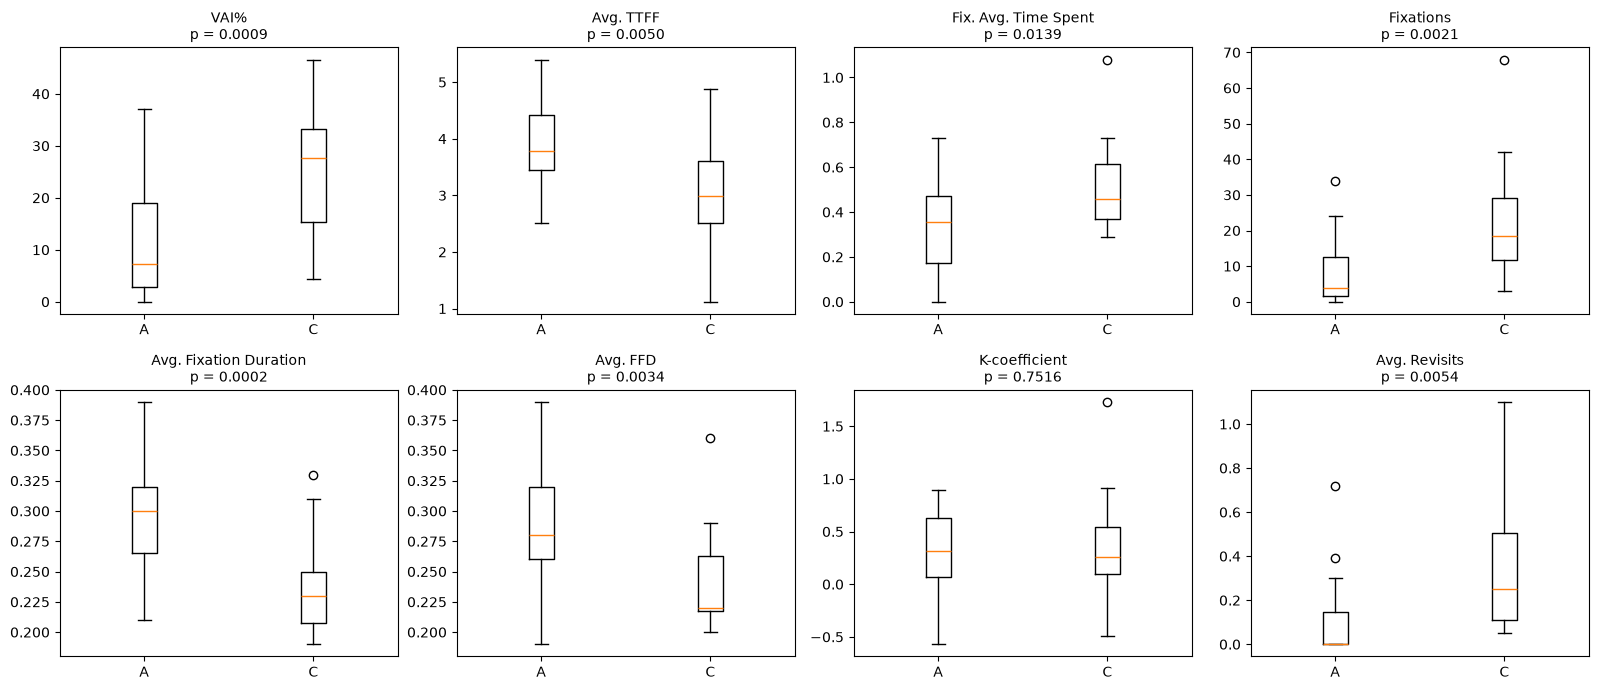

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, m in zip(axes.ravel(), metrics):
    ax.boxplot([a[m].dropna(), c[m].dropna()])
    ax.set_xticklabels(["A", "C"])
    p = results.loc[results["metric"] == m, "p"].iloc[0]
    ax.set_title(f"{m}\np = {p:.4f}", fontsize=10)
plt.tight_layout()
plt.show()